# Unsupervised bearing fault detection under operating-condition shift

In [10]:
import os, subprocess, sys
from pathlib import Path
from collections import Counter
import yaml

In [1]:
REPO_URL = 'https://github.com/Syedurehan70/bearing-ae.git'
CONFIG   = 'configs/dense_logspec.yaml'

os.chdir('/kaggle/working')
if not os.path.isdir('bearing-ae'):
    subprocess.run(['git', 'clone', '--quiet', REPO_URL, 'bearing-ae'], check=True)
os.chdir('/kaggle/working/bearing-ae')
print(subprocess.run(['git','rev-parse','--short','HEAD'], capture_output=True, text=True).stdout.strip())

33f9a03


## 1. Inspecting dataset

In [13]:
mats = sorted(Path('/kaggle/input').rglob('*.mat'))
print(f'{len(mats)} .mat files under /kaggle/input')
for p in mats[:15]:
    print(' ', p)
print('\n')
print(Counter(p.parent.as_posix() for p in mats).most_common(10))

161 .mat files under /kaggle/input
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/100.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/105.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/106.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/107.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/108.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/109.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/110.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/111.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/112.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/118.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/119.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/120.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/121.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/122.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/123.mat


[('

## 2. Pointing config at the data

In [7]:
cfg = yaml.safe_load(open(CONFIG))
cfg['data']['roots'] = ['/kaggle/input/datasets/sufian79/cwru-mat-full-dataset']
cfg['data']['exclude'] = [] 
cfg['data']['include'] = []  

run_cfg = '/kaggle/working/config_run.yaml'
yaml.safe_dump(cfg, open(run_cfg, 'w'), sort_keys=False)
print(open(run_cfg).read())

seed: 1337
device: auto
data:
  roots:
  - /kaggle/input/datasets/sufian79/cwru-mat-full-dataset
  channel: DE
  include: []
  exclude: []
  target_rate: 12000
  sample_rate:
    default: 12000
    normal_baseline: 48000
    path_rules:
      48k: 48000
      48khz: 48000
features:
  representation: logspec
  window: 2048
  hop: 1024
model:
  kind: dense
  hidden:
  - 256
  - 64
  latent: 16
training:
  epochs: 60
  batch_size: 128
  lr: 0.001
  patience: 8
  min_delta: 1.0e-05
experiment:
  train_load: 0
  val_fraction: 0.2
  threshold_quantile: 0.99
  run_kurtosis_baseline: true



## 3. Training

In [8]:
!python -m src.main --config {run_cfg} --out results

2026-07-23 19:02:30,023 | INFO | device: cpu
2026-07-23 19:02:31,370 | INFO | 
40 runs loaded
label                           samples  source Hz  seconds
ball_0.007_0hp                  122,571     12,000     10.2
ball_0.007_1hp                  121,410     12,000     10.1
ball_0.007_2hp                  121,556     12,000     10.1
ball_0.007_3hp                  121,556     12,000     10.1
ball_0.014_0hp                  121,846     12,000     10.2
ball_0.014_1hp                  122,136     12,000     10.2
ball_0.014_2hp                  121,991     12,000     10.2
ball_0.014_3hp                  122,136     12,000     10.2
ball_0.021_0hp                  121,991     12,000     10.2
ball_0.021_1hp                  121,701     12,000     10.1
ball_0.021_2hp                  122,136     12,000     10.2
ball_0.021_3hp                  122,136     12,000     10.2
inner_race_0.007_0hp            121,265     12,000     10.1
inner_race_0.007_1hp            121,991     12,000     10.2
inner_

## 4. Results


{
  "n_parameters": 560784,
  "threshold": 1.3163433074951172,
  "epochs_run": 42,
  "same_load": {
    "n_windows": 1069,
    "n_healthy": 11,
    "n_faulty": 1058,
    "false_positive_rate": 0.09090909090909091,
    "true_positive_rate": 1.0,
    "roc_auc": 1.0,
    "average_precision": 0.9999999999999999,
    "recall_by_fault": {
      "ball_0.007_0hp": 1.0,
      "ball_0.014_0hp": 1.0,
      "ball_0.021_0hp": 1.0,
      "inner_race_0.007_0hp": 1.0,
      "inner_race_0.014_0hp": 1.0,
      "inner_race_0.021_0hp": 1.0,
      "outer_race@6_0.007_0hp": 1.0,
      "outer_race@6_0.014_0hp": 1.0,
      "outer_race@6_0.021_0hp": 1.0
    }
  },
  "shifted_load": {
    "n_windows": 3527,
    "n_healthy": 351,
    "n_faulty": 3176,
    "false_positive_rate": 1.0,
    "true_positive_rate": 1.0,
    "roc_auc": 1.0,
    "average_precision": 1.0
  },
  "false_positive_rate_by_load": {
    "0": 0.09090909090909091,
    "1": 1.0,
    "2": 1.0,
    "3": 1.0
  },
  "kurtosis_baseline": {
    "n_windo

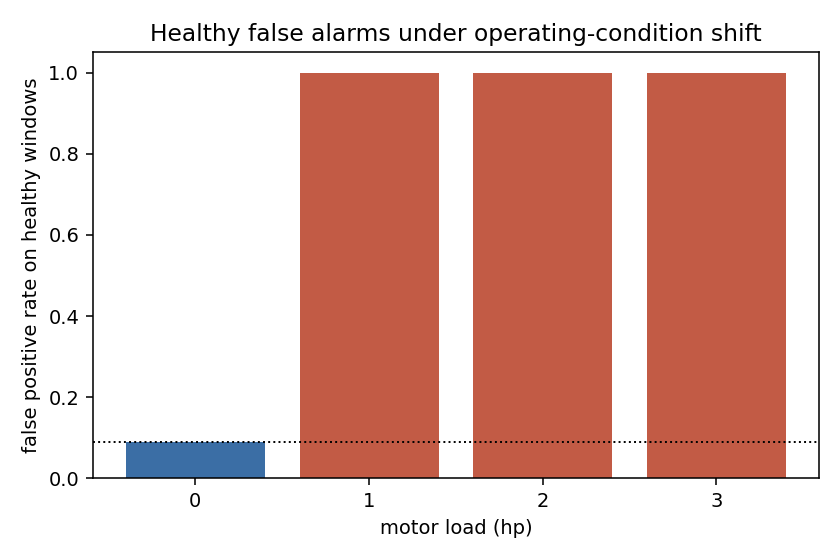

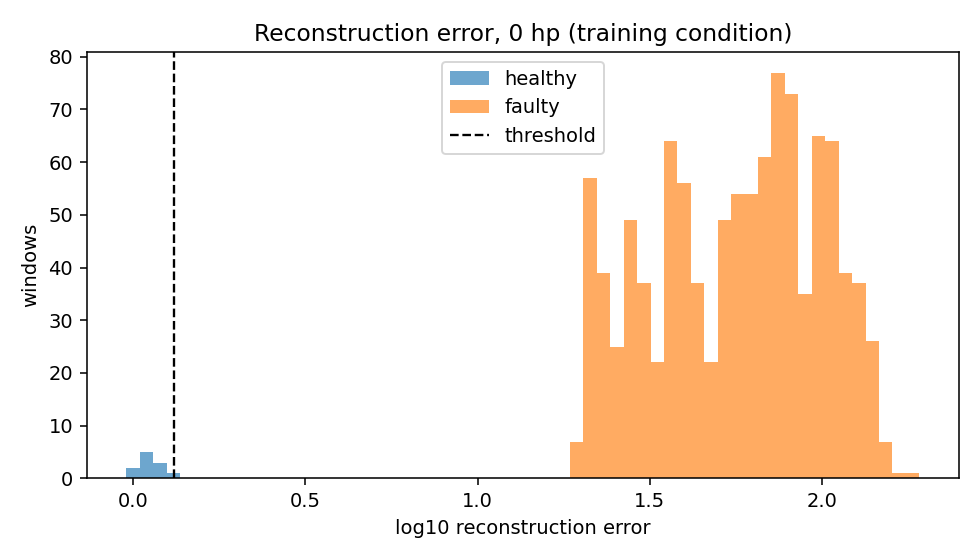

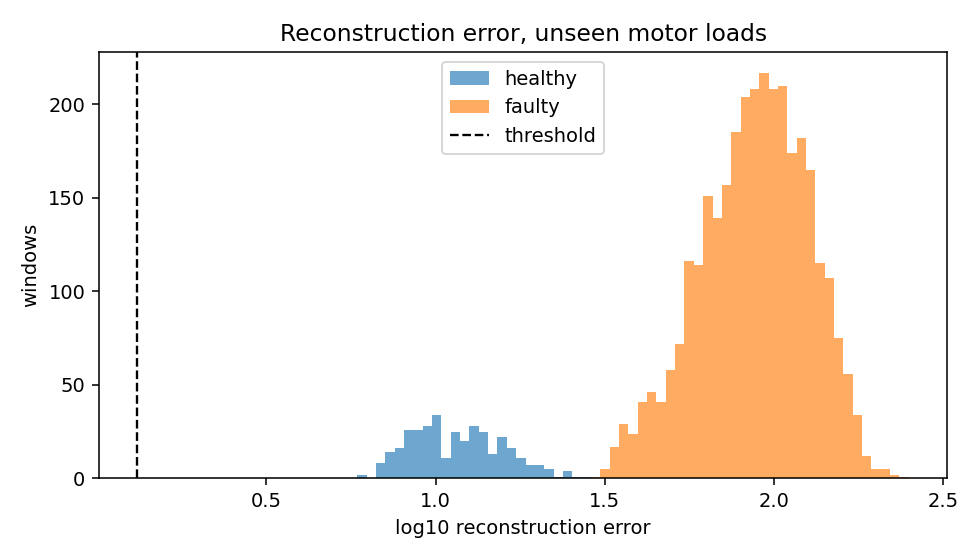

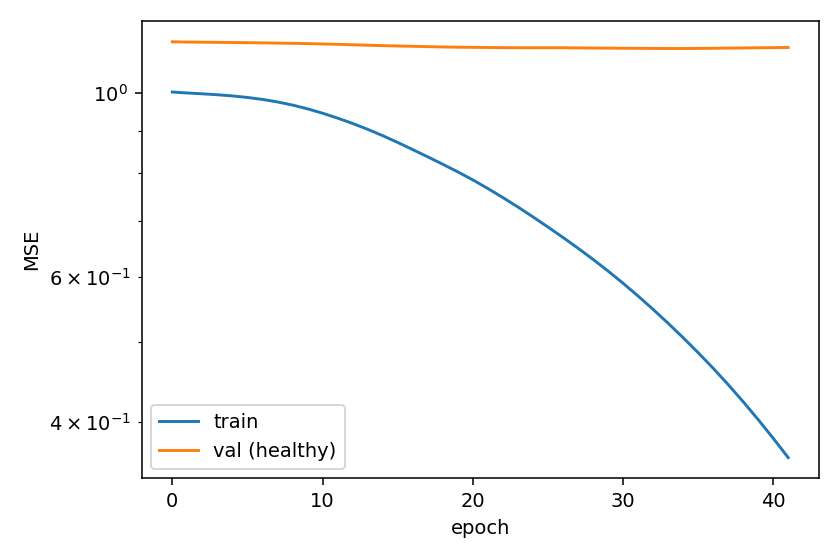

In [9]:
import json
from IPython.display import Image, display

metrics = json.load(open('results/metrics.json'))
print(json.dumps({k: v for k, v in metrics.items() if k != 'config'}, indent=2))

for fig in ['fpr_by_load.png', 'scores_train_load.png', 'scores_shifted_loads.png', 'training_curve.png']:
    path = Path('results') / fig
    if path.exists():
        display(Image(str(path)))
